In [1]:
import pandas as pd

# 1. Read the datasets (treating them as CSVs based on their internal structure)
df_saudi = pd.read_csv("update_saudi_dataset.csv")
df_new = pd.read_csv("New_Maternal_Health_Dataset.csv")

# 2. Combine the datasets
# ignore_index=True resets the row numbers so they flow sequentially from 0 to N
combined_df = pd.concat([df_saudi, df_new], ignore_index=True, sort=False)

# 3. Check the combined data
print(f"Saudi dataset shape: {df_saudi.shape}")
print(f"New dataset shape: {df_new.shape}")
print(f"Combined dataset shape: {combined_df.shape}")

# Display the first few rows and the column structure
print("\nFirst 5 rows of combined dataset:")
print(combined_df.head())

# 4. Save the combined dataset to a new file (properly formatted as CSV)
output_filename = "Combined_Maternal_Health_Dataset.csv"
combined_df.to_csv(output_filename, index=False)
print(f"\nSuccessfully saved combined dataset as {output_filename}")

Saudi dataset shape: (1500, 9)
New dataset shape: (380, 7)
Combined dataset shape: (1880, 9)

First 5 rows of combined dataset:
   Age Pre_pregnancy_BMI  Parity  SystolicBP  DiastolicBP   BS  BodyTemp  \
0   31             Obese     6.0         140           94  7.0      98.6   
1   24            Normal     2.0         160           91  6.3      98.0   
2   34        Overweight     3.0         126           70  7.2      99.8   
3   35            Normal     3.0         113           73  7.7      97.4   
4   18            Normal     0.0         108           61  6.9      98.3   

   HeartRate  RiskLevel  
0         73   low risk  
1         79  high risk  
2        102  high risk  
3         75   low risk  
4         85   low risk  

Successfully saved combined dataset as Combined_Maternal_Health_Dataset.csv


In [3]:
import pandas as pd

try:
    df = pd.read_csv("Combined_Maternal_Health_Dataset.csv")
    print(df.columns.tolist())
except Exception as e:
    print("Error:", e)

['Age', 'Pre_pregnancy_BMI', 'Parity', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


In [5]:
print(df.head(10))

   Age Pre_pregnancy_BMI  Parity  SystolicBP  DiastolicBP   BS  BodyTemp  \
0   31             Obese     6.0         140           94  7.0      98.6   
1   24            Normal     2.0         160           91  6.3      98.0   
2   34        Overweight     3.0         126           70  7.2      99.8   
3   35            Normal     3.0         113           73  7.7      97.4   
4   18            Normal     0.0         108           61  6.9      98.3   
5   22            Normal     0.0         106           68  6.0      98.8   
6   30            Normal     2.0         105           80  7.7      98.7   
7   28             Obese     3.0         114           77  7.2      98.4   
8   30        Overweight     2.0         121           69  6.1      98.7   
9   25            Normal     0.0         124           78  7.9      98.0   

   HeartRate  RiskLevel  
0         73   low risk  
1         79  high risk  
2        102  high risk  
3         75   low risk  
4         85   low risk  
5      

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1880 entries, 0 to 1879
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1880 non-null   int64  
 1   Pre_pregnancy_BMI  1500 non-null   str    
 2   Parity             1500 non-null   float64
 3   SystolicBP         1880 non-null   int64  
 4   DiastolicBP        1880 non-null   int64  
 5   BS                 1880 non-null   float64
 6   BodyTemp           1880 non-null   float64
 7   HeartRate          1880 non-null   int64  
 8   RiskLevel          1880 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 132.3 KB
None


In [7]:
import pandas as pd

# Load the combined dataset
df = pd.read_csv("Combined_Maternal_Health_Dataset.csv")

# Print the missing values per column
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Age                    0
Pre_pregnancy_BMI    380
Parity               380
SystolicBP             0
DiastolicBP            0
BS                     0
BodyTemp               0
HeartRate              0
RiskLevel              0
dtype: int64


### Handling Missing Values

In [11]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("Combined_Maternal_Health_Dataset.csv")

# 1. Handle Categorical Missing Data (BMI)
# Replace NaN with 'Unknown'
df['Pre_pregnancy_BMI'] = df['Pre_pregnancy_BMI'].fillna('Unknown')

# 2. Handle Numeric Missing Data (Parity) using Iterative Imputer
# We isolate the numerical columns to help predict the missing Parity values
numeric_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'Parity']
imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), max_iter=10, random_state=42)

# Fit and transform the numerical columns
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df[numeric_cols]), columns=numeric_cols)

# Update the original dataframe with the imputed Parity column (rounded since pregnancies are whole numbers)
df['Parity'] = df_numeric_imputed['Parity'].round()

print("Missing values after processing:\n", df.isnull().sum()) 

# Save the file as requested
output_file = "impuated_Combined_files.csv"
df.to_csv(output_file, index=False)
print(f"\nSaved file as {output_file}")

Missing values after processing:
 Age                  0
Pre_pregnancy_BMI    0
Parity               0
SystolicBP           0
DiastolicBP          0
BS                   0
BodyTemp             0
HeartRate            0
RiskLevel            0
dtype: int64

Saved file as impuated_Combined_files.csv


In [12]:
import pandas as pd

df = pd.read_csv("impuated_Combined_files.csv")
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


### Analysing Missing Values

In [14]:
import pandas as pd

# Load the combined dataset (before imputation)
df = pd.read_csv("Combined_Maternal_Health_Dataset.csv")

# Calculate missing value percentages
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create a clean summary table
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': missing_percent.round(2)
})

print("Missing Values Summary:")
print(missing_summary)

Missing Values Summary:
                   Missing Count  Percentage (%)
Age                            0            0.00
Pre_pregnancy_BMI            380           20.21
Parity                       380           20.21
SystolicBP                     0            0.00
DiastolicBP                    0            0.00
BS                             0            0.00
BodyTemp                       0            0.00
HeartRate                      0            0.00
RiskLevel                      0            0.00


In [16]:
import pandas as pd

# 1. Load the raw combined dataset
df = pd.read_csv("Combined_Maternal_Health_Dataset.csv")

# 2. Isolate the rows that contain missing values (NaN)
df_missing = df[df.isnull().any(axis=1)]

# 3. Define the physiological columns to check for duplicates
subset_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# 4. Find duplicates among these missing-value rows
duplicate_rows = df_missing[df_missing.duplicated(subset=subset_cols, keep=False)]

# 5. Group by the physiological columns and count unique RiskLevel labels
conflicts = duplicate_rows.groupby(subset_cols)['RiskLevel'].nunique()

# 6. Filter to see if any duplicate group has more than 1 distinct RiskLevel
actual_conflicts = conflicts[conflicts > 1]

# 7. Print the final result cleanly
if actual_conflicts.empty:
    print("no conflicts")
else:
    print("Conflicting RiskLevels found:\n", actual_conflicts.value_counts())




no conflicts


### Identifying combination Features

In [17]:
import pandas as pd

# 1. Load the combined dataset
df = pd.read_csv("impuated_Combined_files.csv")

# 2. Define the physiological feature columns
feature_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# 3. Find feature combinations that have more than one RiskLevel
conflicts = (
    df.groupby(feature_cols)["RiskLevel"]
      .nunique()
      .reset_index(name="n_risk_levels")
)

# 4. Filter for only the combinations with conflicts
conflicts = conflicts[conflicts["n_risk_levels"] > 1]

print(conflicts)

Empty DataFrame
Columns: [Age, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, n_risk_levels]
Index: []


In [18]:
import pandas as pd

# Load the imputed combined dataset
df = pd.read_csv("impuated_Combined_files.csv")

feature_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# Show the actual RiskLevel values for each conflicting combination
conflicts_with_labels = (
    df.groupby(feature_cols)["RiskLevel"]
      .agg(["nunique", lambda x: list(x.unique())])
      .reset_index()
)

conflicts_with_labels.columns = feature_cols + ["n_risk_levels", "risk_levels"]

conflicts_with_labels = conflicts_with_labels[
    conflicts_with_labels["n_risk_levels"] > 1
]

print(conflicts_with_labels)

Empty DataFrame
Columns: [Age, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, n_risk_levels, risk_levels]
Index: []


#### Identifying Outliers for the Combined Dataset

In [19]:
import pandas as pd
import numpy as np

# Load the current working dataset
df = pd.read_csv("impuated_Combined_files.csv")
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Compute IQR Bounds for each column
for col in features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col}: {len(outliers)} outliers outside [{lower_limit:.2f}, {upper_limit:.2f}]")

Age: 52 outliers outside [9.00, 49.00]
SystolicBP: 151 outliers outside [86.50, 146.50]
DiastolicBP: 0 outliers outside [49.00, 105.00]
BS: 250 outliers outside [4.30, 10.70]
BodyTemp: 98 outliers outside [96.50, 99.70]
HeartRate: 5 outliers outside [51.50, 103.50]


### Initial Target-Class Distribution for the combined dataset

In [24]:
import pandas as pd

# Load the imputed combined dataset
df = pd.read_csv("impuated_Combined_files.csv")

# Display the target class distribution
counts = df["RiskLevel"].value_counts()
proportions = df["RiskLevel"].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({
    'Count': counts, 
    'Percentage (%)': proportions.round(3)
})

print(target_dist)

           Count  Percentage (%)
RiskLevel                       
low risk     780          41.489
mid risk     623          33.138
high risk    477          25.372


### Statistical overview of numerical columns

In [20]:
import pandas as pd

# Load the data (using our clean, imputed dataset)
df = pd.read_csv("impuated_Combined_files.csv")
print(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

# Breakdown of the target variable (RiskLevel)
counts = df['RiskLevel'].value_counts()
proportions = df['RiskLevel'].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({'Count': counts, 'Percentage (%)': proportions.round(2)})
print("\n", target_dist)

              count        mean        std   min    50%    max
Age          1880.0   29.555319   8.025380  10.0   29.0   70.0
Parity       1880.0    2.203723   1.709469   0.0    2.0    8.0
SystolicBP   1880.0  117.902660  15.664477  70.0  117.0  160.0
DiastolicBP  1880.0   77.968617  10.732193  49.0   77.0  100.0
BS           1880.0    8.081101   2.365070   6.0    7.3   19.0
BodyTemp     1880.0   98.174947   0.914524  96.1   98.0  103.0
HeartRate    1880.0   77.926596   9.454067  60.0   78.0  112.0

            Count  Percentage (%)
RiskLevel                       
low risk     780           41.49
mid risk     623           33.14
high risk    477           25.37


### Descriptive Statiscal Overview

In [21]:
import pandas as pd

# Load the imputed dataset
df = pd.read_csv("impuated_Combined_files.csv")

# Overall descriptive statistics for numerical columns
desc_num = df.describe().T
print("Numerical Descriptive Stats:\n", desc_num)

# Descriptive stats by RiskLevel to see the differences
grouped_stats = df.groupby("RiskLevel")[['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']].mean().round(2)
print("\nMean Values by Risk Level:\n", grouped_stats)

Numerical Descriptive Stats:
               count        mean        std   min    25%    50%    75%    max
Age          1880.0   29.555319   8.025380  10.0   24.0   29.0   34.0   70.0
Parity       1880.0    2.203723   1.709469   0.0    1.0    2.0    3.0    8.0
SystolicBP   1880.0  117.902660  15.664477  70.0  109.0  117.0  124.0  160.0
DiastolicBP  1880.0   77.968617  10.732193  49.0   70.0   77.0   84.0  100.0
BS           1880.0    8.081101   2.365070   6.0    6.7    7.3    8.3   19.0
BodyTemp     1880.0   98.174947   0.914524  96.1   97.7   98.0   98.5  103.0
HeartRate    1880.0   77.926596   9.454067  60.0   71.0   78.0   84.0  112.0

Mean Values by Risk Level:
              Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
RiskLevel                                                           
high risk  31.86      129.64        85.69  9.68     98.33      79.40
low risk   28.02      110.58        73.71  7.18     98.10      77.13
mid risk   29.72      118.08        77.38  7.98  

### Review Potentially Abnormal Clinical Values

In [26]:
import pandas as pd

# Load the working dataset
df = pd.read_csv("impuated_Combined_files.csv")

# Define abnormal/extreme clinical thresholds (values that might indicate data entry errors)
# These are broad limits for human viability / typical extreme pregnancy cases
abnormal_conditions = {
    "Age_Too_Young (< 12)": df["Age"] < 12,
    "Age_Too_Old (> 55)": df["Age"] > 55,
    "Systolic_Too_Low (< 70)": df["SystolicBP"] < 70,
    "Systolic_Too_High (> 200)": df["SystolicBP"] > 200,
    "Diastolic_Too_Low (< 40)": df["DiastolicBP"] < 40,
    "Diastolic_Too_High (> 120)": df["DiastolicBP"] > 120,
    "BS_Too_Low (< 3.0 mmol/L)": df["BS"] < 3.0,
    "BS_Too_High (> 25.0 mmol/L)": df["BS"] > 25.0,
    "Temp_Too_Low (< 95 F)": df["BodyTemp"] < 95.0,
    "Temp_Too_High (> 104 F)": df["BodyTemp"] > 104.0,
    "HeartRate_Too_Low (< 50 bpm)": df["HeartRate"] < 50,
    "HeartRate_Too_High (> 150 bpm)": df["HeartRate"] > 150,
    "Parity_Extreme (> 15)": df["Parity"] > 15
}

# Check counts for each condition
print("Count of potentially abnormal/impossible clinical values:")
for condition_name, condition_mask in abnormal_conditions.items():
    count = condition_mask.sum()
    if count > 0:
        print(f"- {condition_name}: {count} cases")
        # Print a few examples
        print(df[condition_mask][['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'Parity', 'RiskLevel']].head(3))
        print("-" * 40)
    else:
        print(f"- {condition_name}: 0 cases")

Count of potentially abnormal/impossible clinical values:
- Age_Too_Young (< 12): 3 cases
      Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate  Parity RiskLevel
1515   10          70           50  6.9      98.0         70     1.0  low risk
1656   10          85           65  6.9      98.0         70     1.0  low risk
1872   10         100           50  6.0      99.0         70     1.0  mid risk
----------------------------------------
- Age_Too_Old (> 55): 21 cases
      Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate  Parity RiskLevel
1532   60         120           80  6.1      98.0         75     4.0  low risk
1550   60          90           65  7.0      98.0         77     5.0  low risk
1582   60          90           65  6.8      98.0         77     5.0  mid risk
----------------------------------------
- Systolic_Too_Low (< 70): 0 cases
- Systolic_Too_High (> 200): 0 cases
- Diastolic_Too_Low (< 40): 0 cases
- Diastolic_Too_High (> 120): 0 cases
- BS_Too_Low (< 3.0

### Removing Abnormal Values

In [27]:
import pandas as pd

# Load the working dataset
df = pd.read_csv("impuated_Combined_files.csv")

# Filter out the extreme age anomalies
df_cleaned = df[(df["Age"] >= 12) & (df["Age"] <= 55)]

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")

# Save the clinically viable dataset
df_cleaned.to_csv("Clinically_Cleaned_Maternal_Health.csv", index=False)
print("\nDataset successfully cleaned and saved.")

Original row count: 1880
Cleaned row count: 1856
Rows removed: 24

Dataset successfully cleaned and saved.


### Post Cleaning for the abnormal values

In [38]:
import pandas as pd
import numpy as np

df = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")

# Map BMI text to numbers so math functions can read it
bmi_mapping = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3, 'Unknown': -1}
df['Pre_pregnancy_BMI'] = df['Pre_pregnancy_BMI'].map(bmi_mapping)

features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'Pre_pregnancy_BMI', 'Parity']

for col in features:
    # Force column to numeric, turning any unmapped text into NaN safely
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col}: {len(outliers)} outliers outside [{lower_limit:.2f}, {upper_limit:.2f}]")


Age: 35 outliers outside [10.50, 46.50]
SystolicBP: 132 outliers outside [86.12, 147.12]
DiastolicBP: 25 outliers outside [51.50, 103.50]
BS: 245 outliers outside [4.30, 10.70]
BodyTemp: 96 outliers outside [96.50, 99.70]
HeartRate: 5 outliers outside [51.50, 103.50]
Pre_pregnancy_BMI: 0 outliers outside [-2.00, 6.00]
Parity: 29 outliers outside [-2.00, 6.00]


### Feature pattern by risk level 

In [42]:
import pandas as pd

# 1. Load your cleaned dataset
df_clean = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")

# 2. Map Pre_pregnancy_BMI text categories to numbers
bmi_mapping = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3,
    'Unknown': -1
}

# Apply mapping and explicitly force the column to be numeric
df_clean['Pre_pregnancy_BMI'] = df_clean['Pre_pregnancy_BMI'].map(bmi_mapping)
df_clean['Pre_pregnancy_BMI'] = pd.to_numeric(df_clean['Pre_pregnancy_BMI'], errors='coerce')

# 3. Define all numerical columns including Parity and Pre_pregnancy_BMI
numeric_cols_all = [
    "Age",
    "Parity",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate",
    "Pre_pregnancy_BMI"
]

# 4. Calculate the mean for each risk level
mean_values = df_clean.groupby("RiskLevel")[numeric_cols_all].mean().round(2)

print(mean_values)

             Age  Parity  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  \
RiskLevel                                                                      
high risk  31.49    2.53      129.61        85.72  9.64     98.34      79.42   
low risk   27.48    1.91      110.80        73.79  7.18     98.09      77.19   
mid risk   29.66    2.23      118.15        77.44  7.99     98.14      77.81   

           Pre_pregnancy_BMI  
RiskLevel                     
high risk               1.70  
low risk                1.05  
mid risk                1.62  


In [41]:
import pandas as pd

# 1. Load your cleaned dataset
df_clean = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")

# 2. Map Pre_pregnancy_BMI text categories to numbers
bmi_mapping = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3,
    'Unknown': -1
}

# Apply mapping and explicitly force the column to be numeric
df_clean['Pre_pregnancy_BMI'] = df_clean['Pre_pregnancy_BMI'].map(bmi_mapping)
df_clean['Pre_pregnancy_BMI'] = pd.to_numeric(df_clean['Pre_pregnancy_BMI'], errors='coerce')

# 3. Define all numerical columns including Parity and Pre_pregnancy_BMI
numeric_cols_all = [
    "Age",
    "Parity",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate",
    "Pre_pregnancy_BMI"
]

# 4. Calculate the median for each risk level
median_values = df_clean.groupby("RiskLevel")[numeric_cols_all].median().round(2)

print(median_values)

            Age  Parity  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate  \
RiskLevel                                                                    
high risk  32.0     2.0       133.0         89.0  8.1      98.0       79.0   
low risk   28.0     2.0       112.0         74.0  7.0      98.0       77.0   
mid risk   30.0     2.0       117.0         77.0  7.4      98.0       78.0   

           Pre_pregnancy_BMI  
RiskLevel                     
high risk                2.0  
low risk                 1.0  
mid risk                 2.0  


### Final Preproessing 

In [43]:
# ========== FINAL SUMMARY ==========
import pandas as pd
df_clean = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")
print("Final shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

print("\nClass distribution:")
print(df_clean["RiskLevel"].value_counts())

print("\nClass percentages:")
print(df_clean["RiskLevel"].value_counts(normalize=True).round(3) * 100)

Final shape: (1856, 9)
Missing values: 0
Duplicate rows: 0

Class distribution:
RiskLevel
low risk     765
mid risk     620
high risk    471
Name: count, dtype: int64

Class percentages:
RiskLevel
low risk     41.2
mid risk     33.4
high risk    25.4
Name: proportion, dtype: float64


 ### Preprocessing Visualizations

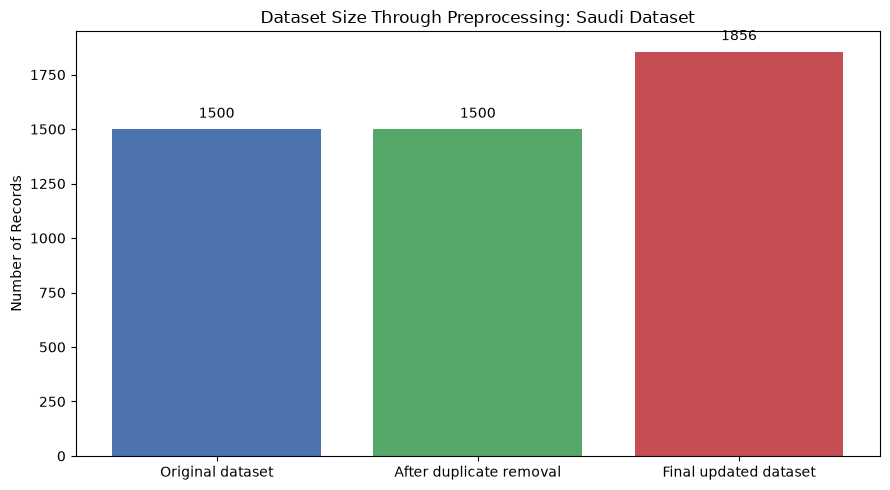

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load both the original and updated Saudi datasets
df = pd.read_csv("update_saudi_dataset.csv")
df_clean = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")

# 2. Calculate dataset size through preprocessing
original_rows = len(df)
exact_duplicates = df.duplicated().sum()
after_duplicates = original_rows - exact_duplicates
final_rows = len(df_clean)

preprocessing_stages = [
    "Original dataset",
    "After duplicate removal",
    "Final updated dataset"
]

row_counts = [
    original_rows,
    after_duplicates,
    final_rows
]

# 3. Create the visualization
plt.figure(figsize=(9, 5))
bars = plt.bar(preprocessing_stages, row_counts, color=['#4c72b0', '#55a868', '#c44e52'])

plt.title("Dataset Size Through Preprocessing: Saudi Dataset")
plt.ylabel("Number of Records")

for bar, count in zip(bars, row_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(row_counts) * 0.02,
        f"{count}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

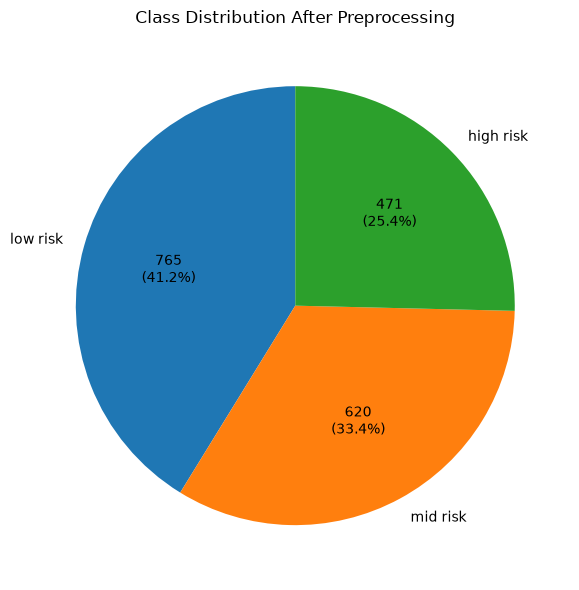

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned dataset
df_clean = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")

# 2. Final RiskLevel distribution after preprocessing
class_counts = df_clean["RiskLevel"].value_counts()

def count_and_percentage(pct):
    total = class_counts.sum()
    count = int(round(pct * total / 100))
    return f"{count}\n({pct:.1f}%)"

# 3. Create the pie chart
plt.figure(figsize=(7, 6))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct=count_and_percentage,
    startangle=90
)

plt.title("Class Distribution After Preprocessing")
plt.tight_layout()
plt.show()


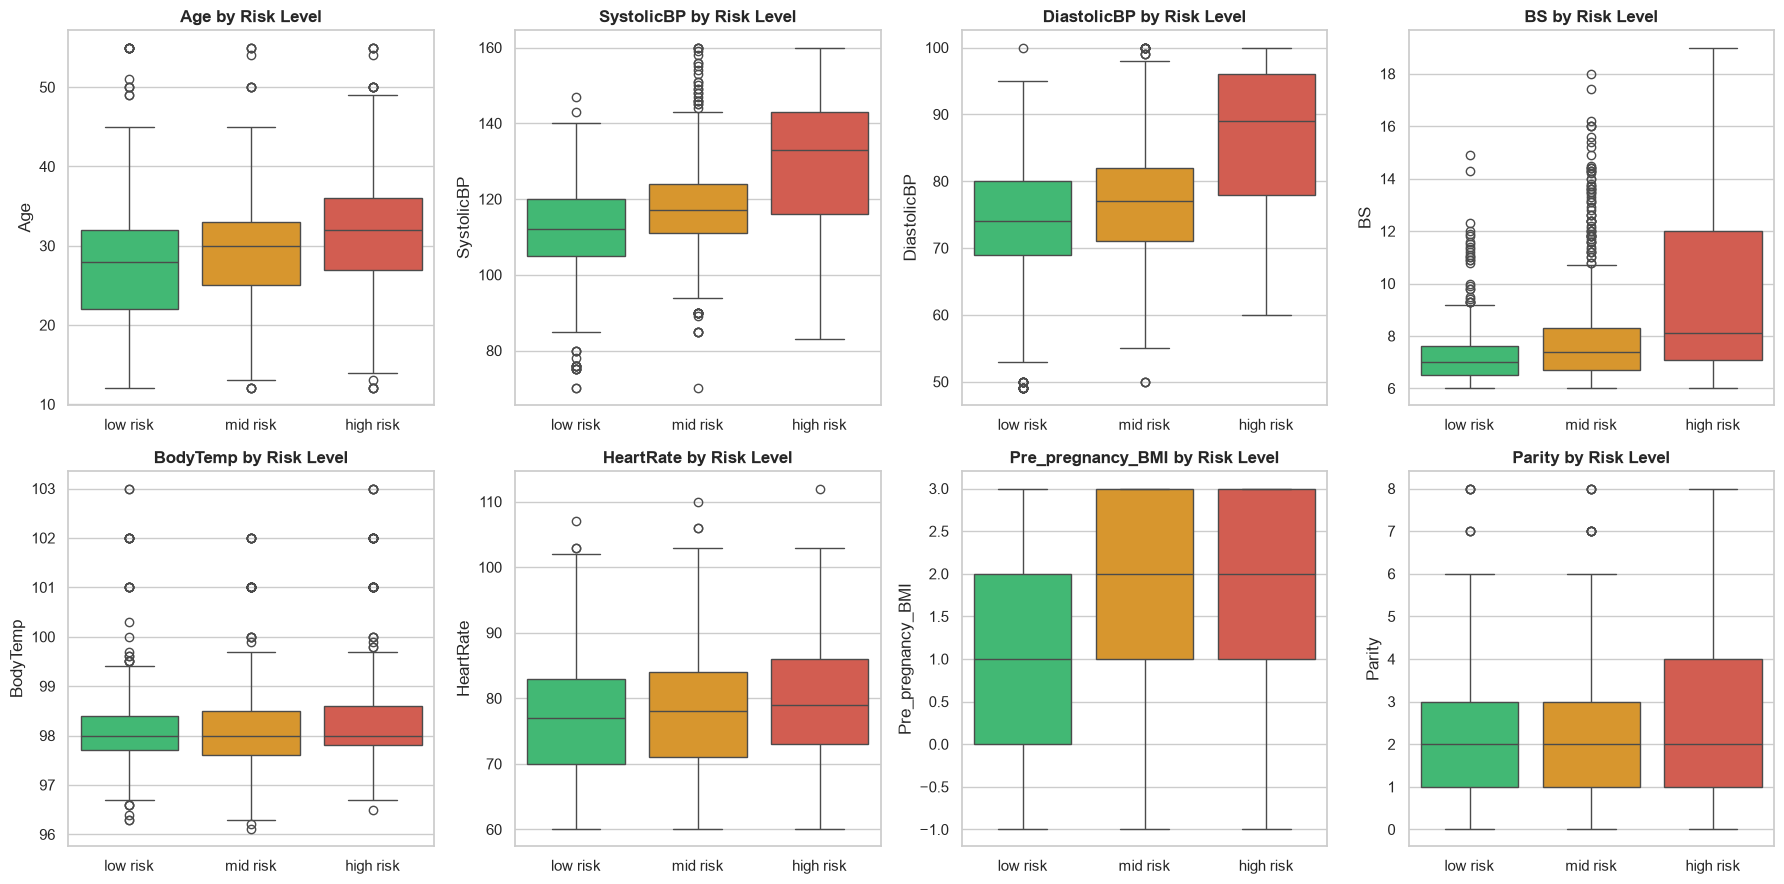

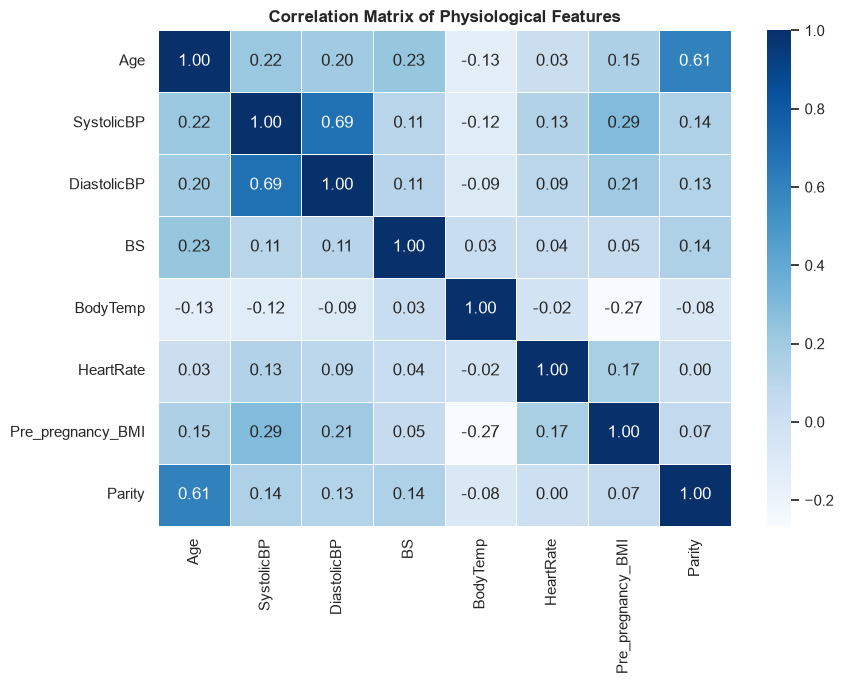

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the specific cleaned dataset
df = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")

# Map Pre_pregnancy_BMI to numerical values so boxplots and correlation work
bmi_mapping = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3,
    'Unknown': -1
}
df['Pre_pregnancy_BMI'] = df['Pre_pregnancy_BMI'].map(bmi_mapping)
df['Pre_pregnancy_BMI'] = pd.to_numeric(df['Pre_pregnancy_BMI'], errors='coerce')

# 1. Boxplots: Compare vitals across risk categories (8 features total)
sns.set_theme(style="whitegrid")
features = [
    'Age', 'SystolicBP', 'DiastolicBP', 'BS', 
    'BodyTemp', 'HeartRate', 'Pre_pregnancy_BMI', 'Parity'
]

# Changed to 2 rows by 4 columns to fit all 8 features perfectly
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

for i, col in enumerate(features):
    sns.boxplot(
        data=df,
        x='RiskLevel',
        y=col,
        hue='RiskLevel',
        order=['low risk', 'mid risk', 'high risk'],
        palette=palette,
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f"{col} by Risk Level", fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# 2. Heatmap: Check multicollinearity
plt.figure(figsize=(9, 7))
sns.heatmap(df[features].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Physiological Features', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the pre-cleaned dataset
df = pd.read_csv("Clinically_Cleaned_Maternal_Health.csv")

features = ('Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
target = 'RiskLevel'
target_order = ['low risk', 'mid risk', 'high risk']
palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

# 2. Skewness and Distribution Statistics
print("=" * 50)
print(f"FEATURE SKEWNESS (Cleaned N={len(df)})")
print("=" * 50)
skew_df = pd.DataFrame({
    'Skewness': df[features].skew(),
    'Kurtosis': df[features].kurtosis()
})
print(skew_df.round(2))

# 3. Plot Histogram & KDE for each vital across Risk Levels
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        data=df,
        x=col,
        hue=target,
        hue_order=target_order,
        palette=palette,
        kde=True,
        element="step",
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col} by Risk Level", fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()